In [49]:
import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, Callback

In [50]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Paper uses unpadded 3x3 convolutions [cite: 82]
        # Adding Batch Normalization for better convergence on brain tumor data
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [51]:
class UNet(pl.LightningModule):
    def __init__(self, in_channels=3, out_classes=1, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        # Contracting Path [cite: 80, 81]
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Expansive Path [cite: 80, 84]
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_classes, kernel_size=1)
        self.criterion = nn.BCEWithLogitsLoss()

    def crop_and_concat(self, upsampled, bypass):
        # Cropping is necessary due to loss of border pixels in unpadded convs [cite: 85]
        diffY = (bypass.size()[2] - upsampled.size()[2]) // 2
        diffX = (bypass.size()[3] - upsampled.size()[3]) // 2
        bypass = bypass[:, :, diffY : diffY + upsampled.size()[2], diffX : diffX + upsampled.size()[3]]
        return torch.cat((bypass, upsampled), dim=1)

    def forward(self, x):
        s1 = self.down1(x); p1 = self.pool(s1)
        s2 = self.down2(p1); p2 = self.pool(s2)
        s3 = self.down3(p2); p3 = self.pool(s3)
        s4 = self.down4(p3); p4 = self.pool(s4)
        
        bn = self.bottleneck(p4)
        
        d4 = self.conv4(self.crop_and_concat(self.up4(bn), s4))
        d3 = self.conv3(self.crop_and_concat(self.up3(d4), s3))
        d2 = self.conv2(self.crop_and_concat(self.up2(d3), s2))
        d1 = self.conv1(self.crop_and_concat(self.up1(d2), s1))
        
        return self.final_conv(d1)

    # --- Metrics & Loss Logic ---
    def dice_coef(self, y_hat, y):
        y_hat = torch.sigmoid(y_hat) > 0.5
        intersection = (y_hat * y).sum()
        return (2. * intersection + 1e-7) / (y_hat.sum() + y.sum() + 1e-7)

    def iou_coef(self, y_hat, y):
        y_hat = torch.sigmoid(y_hat) > 0.5
        intersection = (y_hat * y).sum()
        union = y_hat.sum() + y.sum() - intersection
        return (intersection + 1e-7) / (union + 1e-7)

    def match_gt_size(self, target, ref):
        diff = (target.size(2) - ref.size(2)) // 2
        return target[:, :, diff:diff+ref.size(2), diff:diff+ref.size(3)]

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        y = self.match_gt_size(y, y_hat)
        loss = self.criterion(y_hat, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        y = self.match_gt_size(y, y_hat)
        val_loss = self.criterion(y_hat, y)
        dice = self.dice_coef(y_hat, y)
        iou = self.iou_coef(y_hat, y)
        self.log_dict({"val_loss": val_loss, "val_dice": dice, "val_iou": iou}, prog_bar=True)

    def configure_optimizers(self):
        # Using Adam instead of SGD for faster and more stable results in brain segmentation
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [52]:
class BrainDataset(Dataset):
    def __init__(self, img_paths, mask_paths):
        self.img_paths = img_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Reading and resizing to paper-recommended 572x572 [cite: 27]
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (572, 572))
        
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (572, 572))
        
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0).float() / 255.0
        return img, mask

In [53]:
class MetricsLogger(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        with open("epoch_results.txt", "a") as f:
            f.write(f"Epoch {trainer.current_epoch}: Loss: {m.get('val_loss'):.4f}, "
                    f"Dice: {m.get('val_dice'):.4f}, IoU: {m.get('val_iou'):.4f}\n")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type              | Params | Mode  | FLOPs
------------------------------------------------------------------
0  | down1      | DoubleConv        | 39.0 K | train | 0    
1  | down2      | DoubleConv        | 221 K  | train | 0    
2  | down3      | DoubleConv        | 886 K  | train | 0    
3  | down4      | DoubleConv        | 3.5 M  | train | 0    
4  | pool       | MaxPool2d         | 0      | train | 0    
5  | bottleneck | DoubleConv        | 14.2 M | train | 0    
6  | up4        | ConvTranspose2d   | 2.1 M  | train | 0    
7  | conv4      | DoubleConv        | 7.1 M  | train | 0    
8  | up3        | ConvTranspose

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


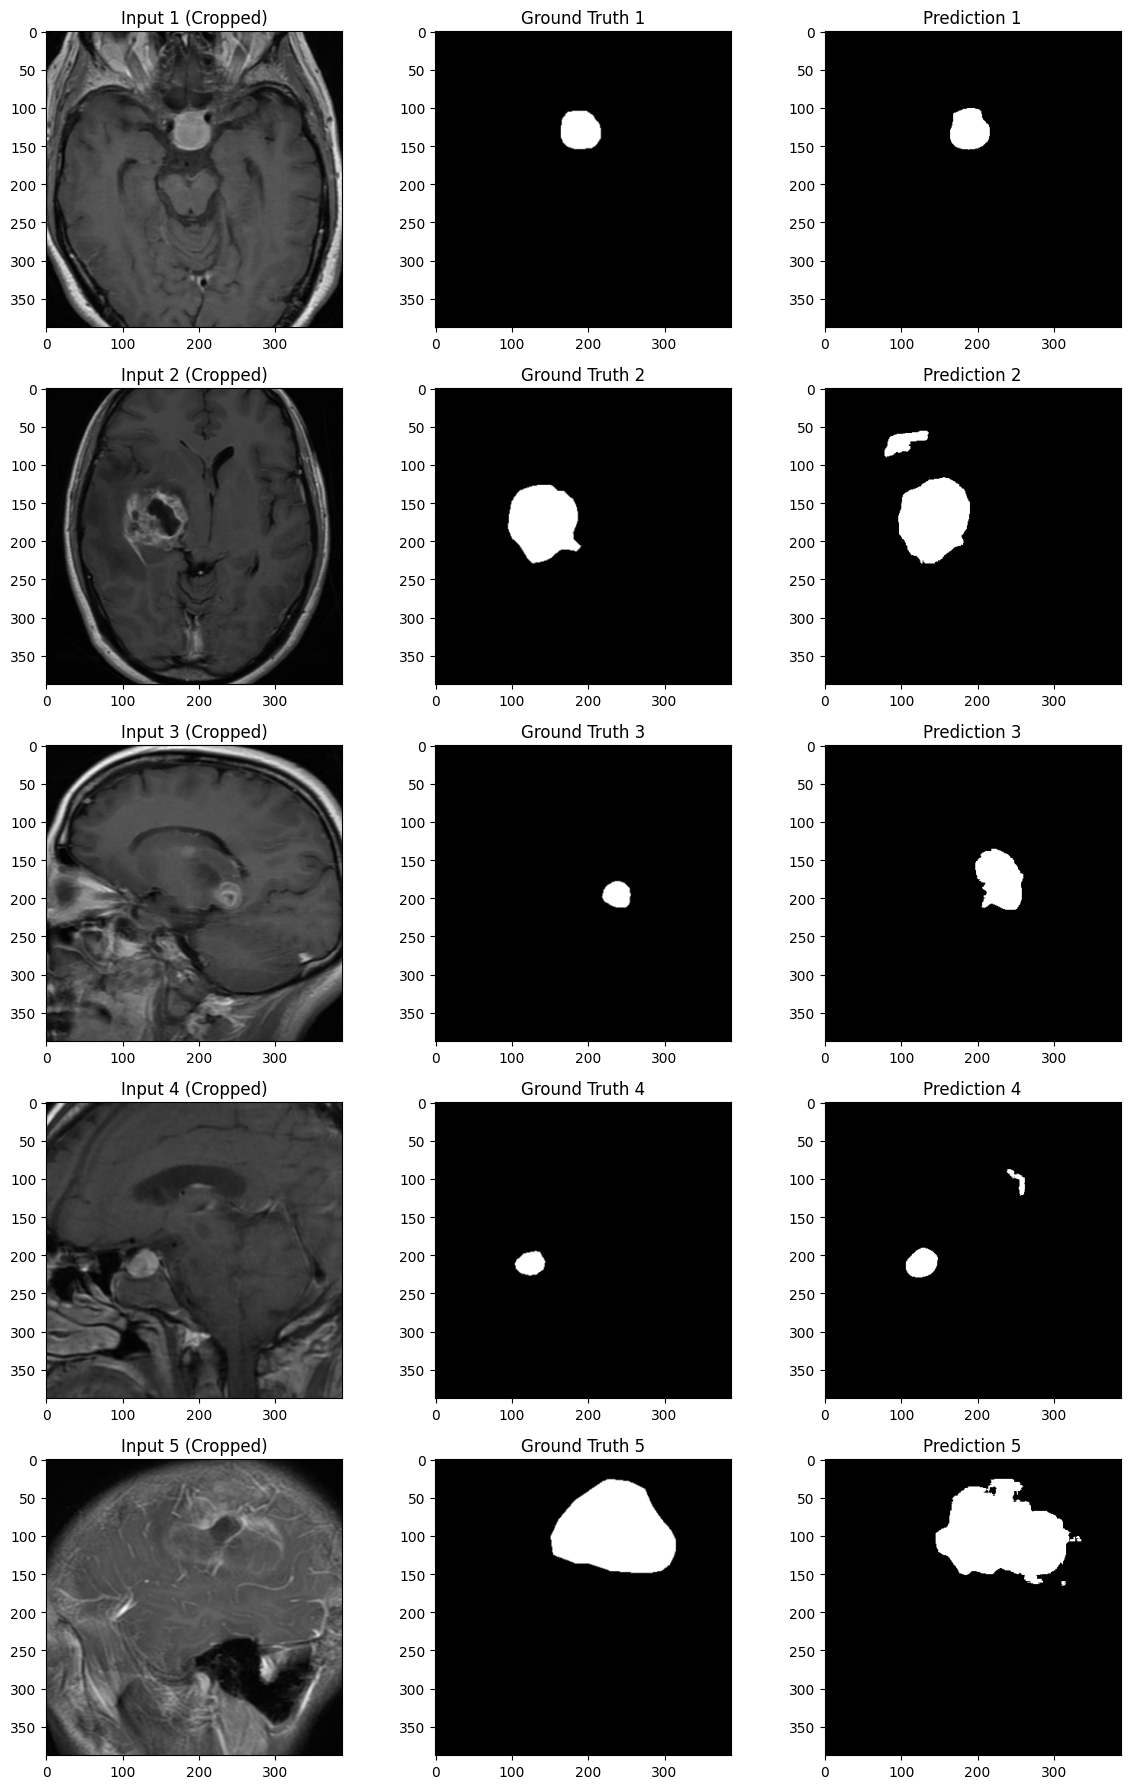

Training completed. Best model saved at: /home/linux-hasan/projects/samsung/lightning_logs/version_11/checkpoints/best_model.ckpt


In [54]:
def run_pipeline():
    # SETUP PATHS (Update folders accordingly)
    image_paths = sorted(glob("dataset/images/*.png"))
    mask_paths = sorted(glob("dataset/masks/*.png"))

    full_ds = BrainDataset(image_paths, mask_paths)
    train_size = int(0.8 * len(full_ds))
    val_size = int(0.1 * len(full_ds))
    test_size = len(full_ds) - train_size - val_size
    train_ds, val_ds, test_ds = random_split(full_ds, [train_size, val_size, test_size])

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=4)
    test_loader = DataLoader(test_ds, batch_size=1)

    # TRAIN
    model = UNet()
    checkpoint = ModelCheckpoint(monitor="val_dice", mode="max", save_top_k=1, filename="best_model")
    trainer = pl.Trainer(max_epochs=20, callbacks=[checkpoint, MetricsLogger()], accelerator="auto")
    trainer.fit(model, train_loader, val_loader)

    # --- TEST & GENERATE RESULTS ---
    best_model = UNet.load_from_checkpoint(checkpoint.best_model_path)
    
    # Determine the device (GPU if available, else CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    best_model.to(device)
    best_model.eval()
    
    # 5 Predictions Visualization
    fig, axes = plt.subplots(5, 3, figsize=(12, 18))
    for i in range(5):
        img, mask = test_ds[i]
        
        # FIX: Move input image to the same device as the model
        input_tensor = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            logits = best_model(input_tensor)
            pred = torch.sigmoid(logits) > 0.5
        
        # FIX: Move tensors back to CPU for visualization and cropping
        # Use .cpu() before calling .numpy()
        img_cpu = img.unsqueeze(0)
        mask_cpu = mask.unsqueeze(0)
        pred_cpu = pred.cpu()
        
        # Crop visuals to match 388x388 unpadded output 
        img_crop = best_model.match_gt_size(img_cpu, pred_cpu).squeeze().permute(1,2,0).numpy()
        mask_crop = best_model.match_gt_size(mask_cpu, pred_cpu).squeeze().numpy()
        pred_final = pred_cpu.squeeze().numpy()
        
        axes[i, 0].imshow(img_crop)
        axes[i, 0].set_title(f"Input {i+1} (Cropped)")
        
        axes[i, 1].imshow(mask_crop, cmap='gray')
        axes[i, 1].set_title(f"Ground Truth {i+1}")
        
        axes[i, 2].imshow(pred_final, cmap='gray')
        axes[i, 2].set_title(f"Prediction {i+1}")

    plt.tight_layout()
    plt.savefig("brain_tumor_final_report.png")
    plt.show()
    print(f"Training completed. Best model saved at: {checkpoint.best_model_path}")

if __name__ == "__main__":
    run_pipeline()